
DETALJAN UPOREDNI PREGLED SVIH METRIKA KROZ SVE SETOVE PODATAKA
                                Silhouette  Davies-Bouldin  Calinski-Harabasz
Set              Algoritam                                                   
Redukovani (SVD) Agglomerative      0.0508          2.6483            62.7866
                 DBSCAN             0.6687          0.4433            41.1844
                 KMeans             0.0676          3.8309            71.2372
                 MiniBatch          0.0517          4.3795            55.3058
                 Spectral           0.0536          3.0102            59.1536
Samo Tekst       Agglomerative      0.0031          8.4375             6.7586
                 DBSCAN             0.0000          0.0000             0.0000
                 KMeans             0.0065         12.6253             8.0446
                 MiniBatch          0.0042          7.4925             7.2083
                 Spectral           0.0048          8.0584             7.4508

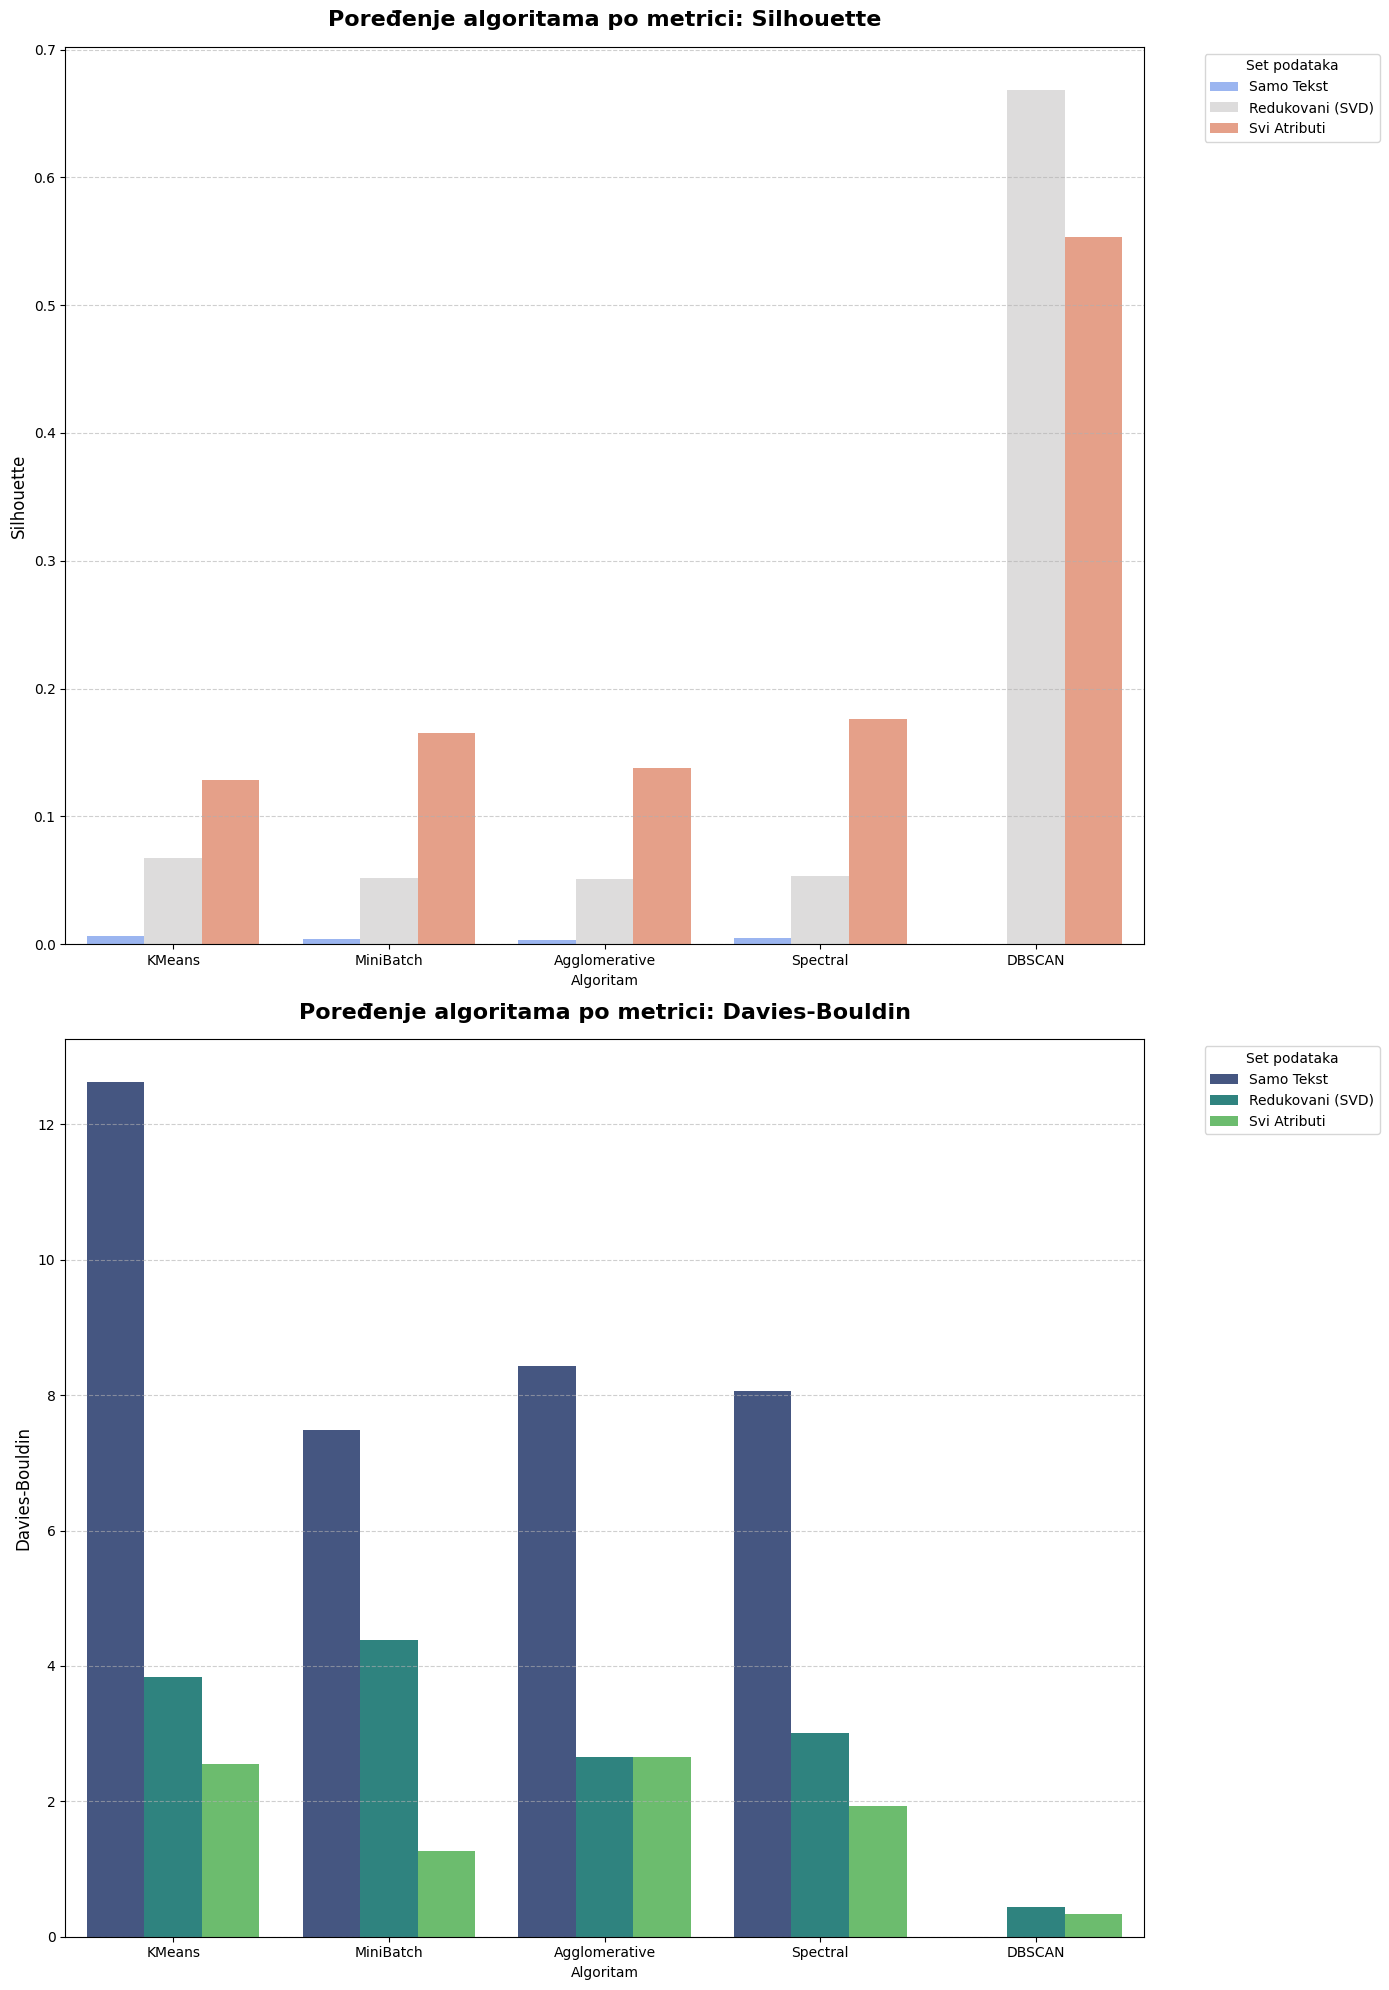

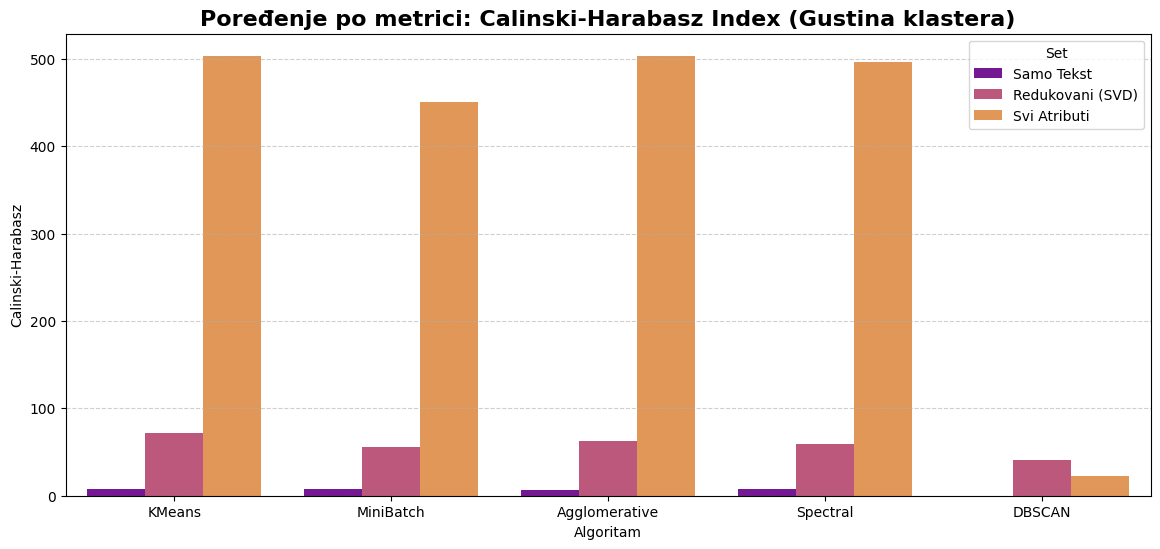


************************************************************
FINALNI IZVEŠTAJ - POBEDNICI PO METRIKAMA
************************************************************
 1. NAJBOLJI SILHOUETTE (Struktura): 
    DBSCAN ('Redukovani (SVD)') -> 0.6687
 2. NAJBOLJI DB INDEX (Razdvojenost): 
    DBSCAN ('Svi Atributi') -> 0.3395
 3. NAJBOLJI CALINSKI-HARABASZ (Gustina/Separacija): 
    Agglomerative ('Svi Atributi') -> 503.50
************************************************************


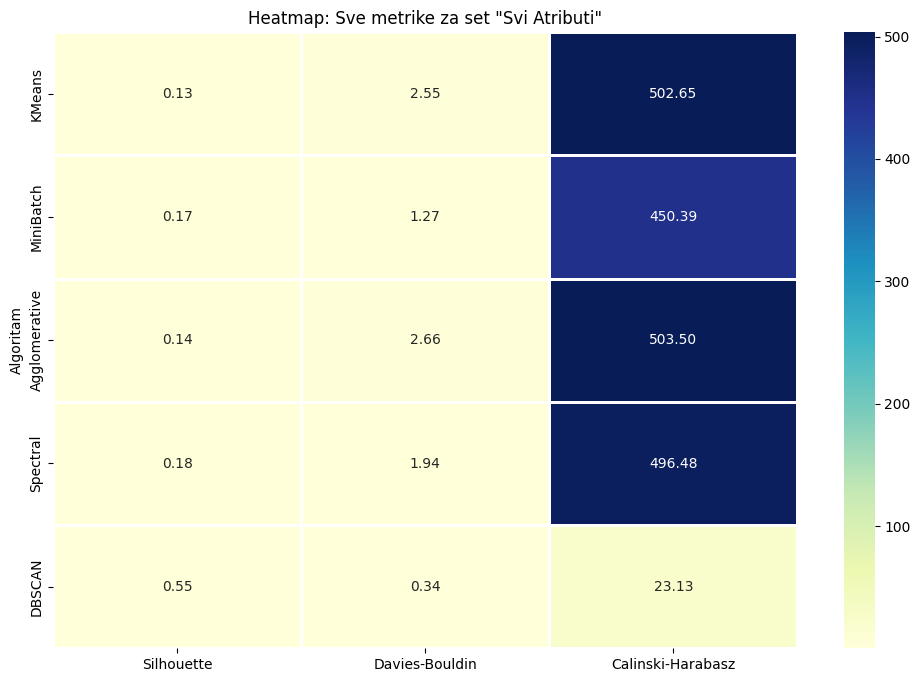

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

try:
    # 1. UCITAVANJE SVA TRI IZVORA
    df_text = pd.read_csv("rezultati_text.csv")
    df_svd = pd.read_csv("rezultati_svd.csv")
    df_all = pd.read_csv("rezultati_all.csv")

    df_text['Set'] = 'Samo Tekst'
    df_svd['Set'] = 'Redukovani (SVD)'
    df_all['Set'] = 'Svi Atributi'

    # Spajanje u Master DataFrame
    df_master = pd.concat([df_text, df_svd, df_all], ignore_index=True)

    # 2. KOMPLETNA UPOREDNA TABELA ZA SVE METRIKE
    print("\n" + "="*85)
    print("DETALJAN UPOREDNI PREGLED SVIH METRIKA KROZ SVE SETOVE PODATAKA")
    print("="*85)
    
    # Pivot tabela koja prikazuje sve metrike (Silhouette, DB, CH)
    finalna_tabela = df_master.pivot_table(index=['Set', 'Algoritam'])
    finalna_tabela = finalna_tabela[['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']]
    
    pd.set_option('display.max_rows', None)
    print(finalna_tabela.round(4))
    print("="*85)

    # 3. POSEBNI GRAFIKONI ZA SVAKU METRIKU
    df_melted = df_master.melt(id_vars=['Algoritam', 'Set'], 
                            value_vars=['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'], 
                            var_name='Metrika', value_name='Vrednost')

    fig, axes = plt.subplots(2, 1, figsize=(14, 20))

    metrike = ['Silhouette', 'Davies-Bouldin']
    palete = ['coolwarm', 'viridis', 'magma']

    for i, metrika in enumerate(metrike):
        sns.barplot(data=df_melted[df_melted['Metrika'] == metrika], 
                    x='Algoritam', y='Vrednost', hue='Set', 
                    ax=axes[i], palette=palete[i])
        axes[i].set_title(f'Poređenje algoritama po metrici: {metrika}', fontsize=16, fontweight='bold', pad=15)
        axes[i].set_ylabel(metrika, fontsize=12)
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)
        axes[i].legend(title='Set podataka', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # 4. POSEBAN GRAFIK ZA CALINSKI-HARABASZ
    plt.figure(figsize=(14, 6))
    sns.barplot(data=df_master, x='Algoritam', y='Calinski-Harabasz', hue='Set', palette='plasma')
    plt.title('Poređenje po metrici: Calinski-Harabasz Index (Gustina klastera)', fontsize=16, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

    # 5. HEATMAPA ZA "SVI ATRIBUTI"
    plt.figure(figsize=(12, 8))
    metrics_all = df_all.set_index('Algoritam')[['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']]
    sns.heatmap(metrics_all, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=1)
    plt.title('Heatmap: Sve metrike za set "Svi Atributi"')

    # 6. ZAKLJUČAK I NAJBOLJI REZULTATI
    best_sil = df_master.loc[df_master['Silhouette'].idxmax()]
    best_ch = df_master.loc[df_master['Calinski-Harabasz'].idxmax()] 
    
    df_db_valid = df_master[df_master['Davies-Bouldin'] > 0]
    if not df_db_valid.empty:
        best_db = df_db_valid.loc[df_db_valid['Davies-Bouldin'].idxmin()]
        db_ispis = f"{best_db['Algoritam']} na setu '{best_db['Set']}' -> {best_db['Davies-Bouldin']:.4f}"
    else:
        db_ispis = "Nema validnih rezultata"
    
    print("\n" + "*"*60)
    print("FINALNI IZVEŠTAJ - POBEDNICI PO METRIKAMA")
    print("*"*60)
    print(f" 1. NAJBOLJI SILHOUETTE (Struktura): \n    {best_sil['Algoritam']} ('{best_sil['Set']}') -> {best_sil['Silhouette']:.4f}")
    print(f" 2. NAJBOLJI DB INDEX (Razdvojenost): \n    {best_db['Algoritam']} ('{best_db['Set']}') -> {best_db['Davies-Bouldin']:.4f}")
    print(f" 3. NAJBOLJI CALINSKI-HARABASZ (Gustina/Separacija): \n    {best_ch['Algoritam']} ('{best_ch['Set']}') -> {best_ch['Calinski-Harabasz']:.2f}")
    print("*"*60)

except Exception as e:
    print(f"Greška: {e}. Proveri da li su nazivi rezultata .csv ispravni!")